In [33]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_classic.prompts import ChatPromptTemplate
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Dict,List
from langchain_community.document_loaders import PyPDFLoader,Docx2txtLoader
import os
from pydantic import BaseModel
from langchain_classic.output_parsers.pydantic import PydanticOutputParser

In [48]:
load_dotenv(r'D:\Projects\AI_Powered_Recruitment_Agent\.env')
groq_api_key = os.environ['GROQ_API_KEY']

llm = ChatGroq(
    model='llama-3.1-8b-instant',#openai/gpt-oss-20b
    api_key=groq_api_key,
    temperature=0,
    max_tokens=150
)

In [35]:
from typing import TypedDict, List, Dict

class ResumeAnalysisState(TypedDict):
    resume_path: str               # Path to resume file
    job_desc: str                  # Job description text

    resume_data: str               # Parsed text content of the resume

    required_skills: List[str]     # Skills extracted from job description
    candidate_skills: List[str]    # Skills extracted from resume
    missing_skills: List[str]      # Skills present in JD but missing in resume
    projects: str

    skills_scores: Dict[str, float]  # Skill-wise score (0-10)

    ats_score: float               # ATS match score (0-100)

    improvement_skills: List[str]  # Skills to improve
    suggestions: List[str]          # Suggestions to improve resume/skills
    project_ideas: List[str]        # Project ideas to cover missing skills
    examples_to_add: List[str]      # Real-world examples to add

In [36]:
def extract_text_from_resume(file):

    """
    Return a cha
    """

    if hasattr(file, "name"):
        ext = file.name.split(".")[-1].lower()
    else:
        ext = file.split(".")[-1].lower()

    if ext == "pdf":
        loader = PyPDFLoader(file)
    elif ext == "docx":
        loader = Docx2txtLoader(file)
    elif ext == "txt":
        with open(file, "r", encoding="utf-8") as f:
            return f.read()
    else:
        return ""
    

    return loader.load()


def extract_resume_data(state: ResumeAnalysisState):
    path = state['resume_path']
    docs = extract_text_from_resume(path)
    combined = ' '
    for doc in docs:
        combined+=' '+doc.page_content
    return {
        'resume_data' : combined
    }


In [37]:
from pydantic import Field
class ResumeSkills(BaseModel):
    skills: List[str] = Field(...,description='List of technical skills of candidate')
    projects: str = Field("No project mentioned", description="Candidate projects or 'No project mentioned'")

    
def extract_info_from_resume(state: ResumeAnalysisState):
    prompt_template = '''
You are a technical hiring expert.

Your task is to **extract all technical skills** from the candidate's resume AND **all projects mentioned**.

IMPORTANT RULES:
1. Only extract skills explicitly mentioned in the resume.
2. Do NOT infer skills that are not present.
3. Focus only on programming languages, frameworks, tools, libraries, and technical knowledge.
4. Return output as **strict JSON** with exactly two keys:
   - "skills": a list of strings of all skills.
   - "projects": a string describing the projects; if no project is mentioned, set it to "No project mentioned".
5. Do not change key names, do not add extra text, do not nest values.
6. Follow the example format exactly.

Resume:
{resume_data}

Output JSON example:
{{"skills": ["Python","SQL","Pandas","NumPy","Machine Learning"], "projects": "Disease Prediction: ML model which predicts disease outcome from patient data"}}
'''
    prompt = ChatPromptTemplate.from_messages([
        ('system','You are a technical hiring expert.'),
        ('user',prompt_template)
    ])
    
    output_parser = PydanticOutputParser(pydantic_object=ResumeSkills)

    chain = prompt | llm | output_parser

    response = chain.invoke({
        'resume_data' : state['resume_data'],

    })
    return {
        'candidate_skills' : response.skills,
        'projects' : response.projects,
    }



In [ ]:
class SkillList(BaseModel):
    skills: List[str] = Field(...,description='List of required technical skills')

def extract_skills_from_jd(state: ResumeAnalysisState):
    prompt_template = '''
You are a technical hiring expert.

Your task is to extract all technical skills from the job description.

RULES:
1. Extract ONLY explicit technical skills mentioned in the job description.
2. Include programming languages, frameworks, libraries, tools, and technical knowledge.
3. RETURN STRICT JSON with a single key "skills" as a list of strings.
4. DO NOT add explanations, markdown, or extra text.
5. If no skills are explicitly mentioned, return a generic set of skills (e.g., ["HTML","CSS","JavaScript","React"]).

Job Description:
{job_desc}

OUTPUT JSON example:
{{"skills": ["Python","SQL","Pandas","NumPy","Machine Learning"]}}
'''
    prompt = ChatPromptTemplate.from_messages([
        ('system','You are a technical hiring expert.'),
        ('user',prompt_template)
    ])
    
    output_parser = PydanticOutputParser(pydantic_object=SkillList)

    chain = prompt | llm | output_parser

    response = chain.invoke({
        'job_desc' : state['job_desc']
    })
    return {
        'required_skills' : response.skills
    }

In [39]:


class SkillAnalysisModel(BaseModel):
    ats_score: float = Field(..., description="ATS match score (0-100)")
    missing_skills: List[str] = Field(default_factory=list, description="Skills present in JD but missing in resume")
    skill_wise_score: Dict[str, float] = Field(default_factory=dict, description="Skill-wise score (0-10) for each required skill")
    improvement_skills: List[str] = Field(default_factory=list, description="Skills that need improvement")
    suggestions: List[str] = Field(default_factory=list, description="Suggestions to improve resume or profile")
    project_ideas: List[str] = Field(default_factory=list, description="Project ideas to cover missing skills")
    examples_to_add: List[str] = Field(default_factory=list, description="Examples or achievements to add")
def skill_analysis(state: ResumeAnalysisState):
    prompt_template = """
You are a strict technical hiring evaluator.

Your task is to **analyze the candidate's skills and projects** against the job requirements.

Inputs:
- Job Requirement Skills: {required_skills}
- Candidate Skills: {candidate_skills}
- Candidate Projects: {projects}

Tasks:
1. Compute an ATS Score (0-100) based on keyword match between job skills and candidate skills/projects.
2. Identify missing skills (skills present in JD but not in candidate skills/projects).
3. Assign a skill-wise score (0-10) for each required skill strictly based on evidence in candidate skills/projects.
4. Suggest skills that need improvement.
5. Give suggestions to improve the resume or candidate profile.
6. Suggest practical project ideas to cover missing skills.
7. Give examples or achievements to add if possible.

Rules:
- Only consider explicitly mentioned skills or projects.
- Return **strict JSON** following this format:

{{
  "ats_score": float,
  "missing_skills": [string],
  "skill_wise_score": {{ "skill_name": float }},
  "improvement_skills": [string],
  "suggestions": [string],
  "project_ideas": [string],
  "examples_to_add": [string]
}}

Do NOT add explanations or extra text.
"""
    # Create ChatPromptTemplate
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a strict technical hiring evaluator."),
        ("user", prompt_template)
    ])

    # Create output parser
    output_parser = PydanticOutputParser(pydantic_object=SkillAnalysisModel)

    # Build chain: prompt | llm | parser
    chain = prompt | llm | output_parser

    # Invoke LLM
    response = chain.invoke({
    "required_skills": state["required_skills"],
    "candidate_skills": state["candidate_skills"],
    "projects": state["projects"]
    })

    # Update state
    state.update({
        "ats_score": response.ats_score,
        "missing_skills": response.missing_skills,
        "skills_scores": response.skill_wise_score,
        "improvement_skills": response.improvement_skills,
        "suggestions": response.suggestions,
        "project_ideas": response.project_ideas,
        "examples_to_add": response.examples_to_add
    })

    return state    
    

In [40]:
graph = StateGraph(ResumeAnalysisState)

graph.add_node('extract_skills_from_jd',extract_skills_from_jd)
graph.add_node('extract_info_from_resume',extract_info_from_resume)
graph.add_node('skill_analysis',skill_analysis)
graph.add_node('extract_resume_data',extract_resume_data)
graph.add_node('merge_for_analysis',lambda state: state) # Dummy Node

graph.add_edge(START,'extract_skills_from_jd')
graph.add_edge('extract_skills_from_jd','merge_for_analysis')

graph.add_edge(START,'extract_resume_data')
graph.add_edge('extract_resume_data','extract_info_from_resume')

graph.add_edge('merge_for_analysis','skill_analysis')
graph.add_edge('extract_info_from_resume','skill_analysis')
graph.add_edge('skill_analysis',END)

agent = graph.compile()


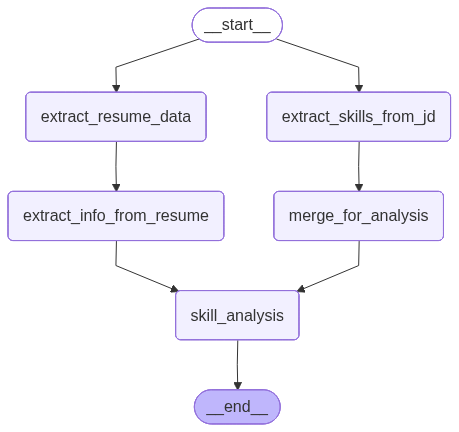

In [41]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())

In [43]:
jd = """
We are seeking a highly motivated AI/ML Engineer to join our data science team. 
The ideal candidate should have strong proficiency in machine learning, deep learning, and data analytics, with experience building and deploying AI solutions.

Required Skills:
- Programming Languages: Python, R, Java
- Machine Learning: Scikit-learn, XGBoost, LightGBM
- Deep Learning: TensorFlow, PyTorch, Keras
- Data Handling: NumPy, Pandas, SQL
- Data Visualization: Matplotlib, Seaborn, Plotly
- Cloud & Tools: AWS, Google Cloud Platform, Docker, Git
- APIs & Deployment: REST APIs, Flask, FastAPI
- Soft Skills: Problem-solving, analytical thinking, teamwork

Preferred Experience:
- Developing and deploying ML/DL models
- Natural Language Processing (NLP) or Computer Vision projects
- Data preprocessing, feature engineering, and model optimization
- Writing clean, modular, and testable code
"""

response = agent.invoke({
    'resume_path' : 'Resume_DSAI.pdf',
    'job_desc' : jd
})

OutputParserException: Invalid json output: 
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 

In [ ]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'job_desc': '\nWe are seeking a highly motivated AI/ML Engineer to join our data science team. \nThe ideal candidate should have strong proficiency in machine learning, deep learning, and data analytics, with experience building and deploying AI solutions.\n\nRequired Skills:\n- Programming Languages: Python, R, Java\n- Machine Learning: Scikit-learn, XGBoost, LightGBM\n- Deep Learning: TensorFlow, PyTorch, Keras\n- Data Handling: NumPy, Pandas, SQL\n- Data Visualization: Matplotlib, Seaborn, Plotly\n- Cloud & Tools: AWS, Google Cloud Platform, Docker, Git\n- APIs & Deployment: REST APIs, Flask, FastAPI\n- Soft Skills: Problem-solving, analytical thinking, teamwork\n\nPreferred Experience:\n- Developing and deploying ML/DL models\n- Natural Language Processing (NLP) or Computer Vision projects\n- Data preprocessing, feature engineering, and model optimization\n- Writing clean, modular, and testable code\n',
 'resume_data': '  Subham  Sahu            

In [ ]:
from typing import Optional
class MarkList(BaseModel):
    marks: list[float]
    name: Optional[str] = "Unknown"  # default if name not found


prompt_text = """
You are an assistant that extracts name and marks from a sentence.

Input: {text}

Rules:
- Extract the person's name (first proper noun) as 'name'.
- If no name is present, set "name" to "Unknown".
- Extract all numbers corresponding to marks in order they appear.
- Return JSON ONLY matching this format: 
  {{ "name": "Person Name", "marks": [number1, number2, ...] }}
- Do not include any extra text or explanation.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a JSON extractor for marks and names."),
    ("user", prompt_text)
])

output_parser = PydanticOutputParser(pydantic_object=MarkList)

chain = prompt | llm | output_parser

response = chain.invoke({
    "text": "My marks in physics "
})

print(response.name)   # Subham
print(response.marks)  # [80.3, 56.3, 76]

Unknown
[]


In [ ]:
from langchain_core.tools import tool
@tool
def job_data(role: str):
    '''Returns the skills required for particular role'''


prompt_template = """
You are a technical hiring expert.

Input: {job_desc}

Rules:
- Extract ALL technical skills explicitly mentioned in the job description.
- Include programming languages, frameworks, libraries, tools, and technical knowledge.
- ALWAYS return JSON with a single key "skills", even if empty.
- If no skills are found, then understand job role and return skills which are required for that particular role.
- Return JSON ONLY. No extra text, explanation, or markdown.

Example JSON output:
{{"skills": ["Python","SQL","Pandas","NumPy","Machine Learning"]}}
"""
prompt = ChatPromptTemplate.from_messages([
        ('system','You are a technical hiring expert.'),
        ('user',prompt_template)
    ])
    
output_parser = PydanticOutputParser(pydantic_object=SkillList)

chain = prompt | llm.bind_tools().with_structured_output(SkillList)

response = chain.invoke({
        'job_desc' : "Devlopment"
    })

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=SkillList> {"skills": ["Development", "Programming", "Coding", "Software Development", "Python", "Java", "C++", "JavaScript", "SQL", "Database Management", "Version Control", "Git", "Agile Methodologies", "Scrum", "Kanban"]}'}}

In [63]:
response

SkillList(skills=['Backend developer', 'latest', 'Python', 'SQL', 'Databases', 'APIs', 'Frameworks', 'Cloud platforms', 'Containerization', 'DevOps', 'Agile methodologies'])

In [5]:
from langchain_community.document_loaders import UnstructuredImageLoader
loader = UnstructuredImageLoaderr('img.jpeg')
loader.load()

ConfigError: unable to infer type for attribute "REGEX"

Note: you may need to restart the kernel to use updated packages.


d:\Projects\AI_Powered_Recruitment_Agent\rec_agent_venv\Scripts\python.exe: No module named uv
